# 06 · PCA

The first thing to do with a table of 38 numbers per cell is to ask what its **largest
sources of variation** are — before clustering it, before embedding it, before believing
anything about it.

Principal component analysis (PCA) answers that literally: it finds the directions along which
the cells vary most, in order. Furthermore, the components one gets from the PCA are given by groups of genes, which you can look at to determine possible biological reasons driving these differences.

| | |
|---|---|
| **1** | Fit the PCA |
| **2** | How much does each component explain? |
| **3** | Colour it by what you already know |
| **4** | What is PC1 made of? |
| **5** | Save the components |

:::{note}
**We use the normalized and subset(only control conditions)** We have previously done the normalization —
[Step 18](../1_preparation/03_normalisation.ipynb) put every value in control-cell SD
units. We also went through how to subset and sketch parts of the data - 
[chapter 04](../1_preparation/04_subsetting_and_sketching.ipynb), here we cut the data to the two
control conditions, which is small enough to use **every cell of**. This chapter opens
that file and starts.
:::

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import stats

plt.rcParams.update({          # the house style, no package needed
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False,
    "legend.frameon": False, "pdf.fonttype": 42, "ps.fonttype": 42,
})
pd.set_option("display.width", 140)

# The tables live here on Euler. Change this line if your copy is elsewhere.
DATA = Path("/cluster/project/mcsliberali/data_mcs_2026")

cells = sc.read_h5ad(DATA / "mcs2026_controls.h5ad")
names = cells.var_names.tolist()
timepoint = cells.obs.timepoint_h.astype(int).values
condition = cells.obs.condition.astype(str).values

print(f"{cells.n_obs:,} cells x {cells.n_vars} markers")
print(f"  conditions: {sorted(cells.obs.condition.astype(str).unique())}")
print(f"  wells: {cells.obs.well.nunique()}   units: {cells.uns['provenance']['units']}")

97,177 cells x 38 markers
  conditions: ['DMSO', 'PBS']
  wells: 32   units: X in control-cell SDs; obs measurements in pixels and ratios


:::{warning}
**Where this chapter writes is the course's folder, not yours.** These chapters were run to
produce the figures you see here, and from chapter 06 onwards they write into
`/cluster/project/mcsliberali/file_outputs`, which you can neither see nor write to.

Load from `data_mcs_2026` once, then save to and read from a folder of your own — see
[Working on Euler](../../setup/working_on_euler.md) for the pattern and the lines to change.
:::

## 1 · Fit the PCA

What goes in is `X`: one row per cell, one column per marker, already centred and scaled
by Stage 1. Twenty components is far more than this data can support — the point of asking
for them is to see where they stop being worth anything.

`sc.pp.pca` does not hand the result back. It writes it **into the object**, in three
slots, and knowing which is most of what there is to know about working in scanpy:

| slot | shape | what it holds |
|---|---|---|
| `obsm["X_pca"]` | cells × components | where each cell landed |
| `varm["PCs"]` | markers × components | the loadings — how each marker builds each component |
| `uns["pca"]["variance_ratio"]` | components | how much of the variance each one explains |

That is the reason to use it rather than `sklearn.decomposition.PCA`, which returns an
object you then have to remember to store. Here the result travels with the cells through
every subset, filter and write that follows.

In [2]:
sc.pp.pca(cells, n_comps=20, random_state=0)
coords = cells.obsm["X_pca"]
print(f"  {cells.n_obs:,} cells x {cells.n_vars} markers -> {coords.shape[1]} components")

  97,177 cells x 38 markers -> 20 components


## 2 · How much does each component explain?

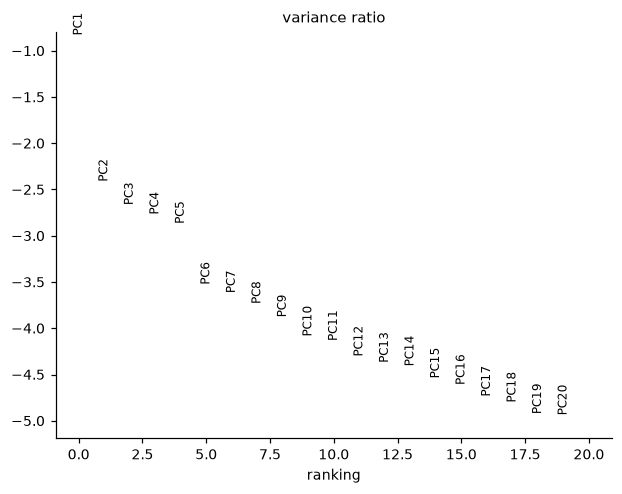

In [3]:
sc.pl.pca_variance_ratio(cells, n_pcs=20, log=True)

## 3 · Colour it by what you already know

A component is only interesting once you know what it distinguishes — so colour the same
points by things that were true before any of this was computed.

This file holds **control cells only**, DMSO and PBS, nothing treated. So the three
things already known about every cell here are *when it was fixed*, *which vehicle it sat
in*, and *where on the plate it grew*. That is the whole list, and it is a useful
constraint: none of these three is a result, so anything one of them explains is
something your biology does not get to claim.

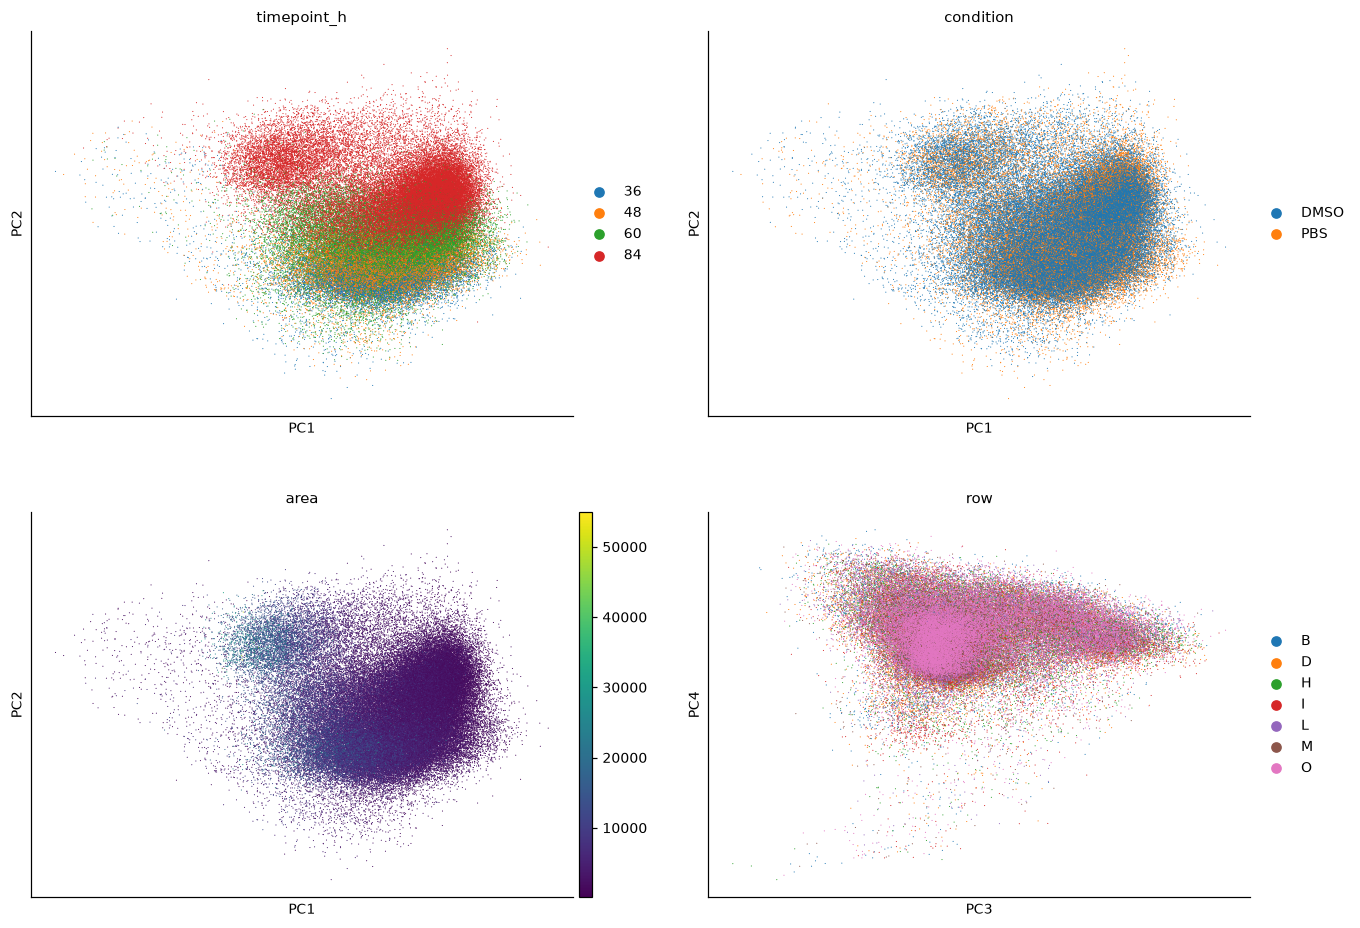

In [4]:
sc.pl.pca(
    cells,
    color=["timepoint_h", "condition", "area", "row"],
    dimensions=[(0, 1), (0, 1), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)

:::{important}
**This is a diagnostic, not a result.** Three questions to ask of it, in order:

1. **Is the strongest separation the timepoint?** If so, PC1 is a clock, and any
   clustering built on it will hand you back timepoints wearing the costume of cell types.
2. **Do the two vehicles separate?** On this plate they do not — and that is *not*
   evidence that they are the same. [Chapter 07](07_umap.ipynb) measures the same pair at
   the well level and finds **11 of the 38 markers** more than a control SD apart, the
   largest by nearly two. A shift of two SDs is small next to the spread of single cells
   within one well, so the clouds overlap while the well means do not. An embedding is a
   picture of the largest variation, not a detector.
3. **Does plate position show?** If one row sits apart from the rest, where a well grew is
   competing with what is in it. Chapter 07 puts a number on that too, and the answer is
   more interesting than the plot suggests: most of what looks like a row effect is really
   the *well* effect, since cells in one well are trivially in one row.

What each of these *means* for the experiment is a question for the analysis, not for
the method. Answer them for your own subset before you plot anything else.
:::

## 4 · What is PC1 made of?

The loadings say which markers build each component. 

You can plot the PCA loadings in different ways:
1. Using the scanpy function
2. As a table
3. Your own costume function 

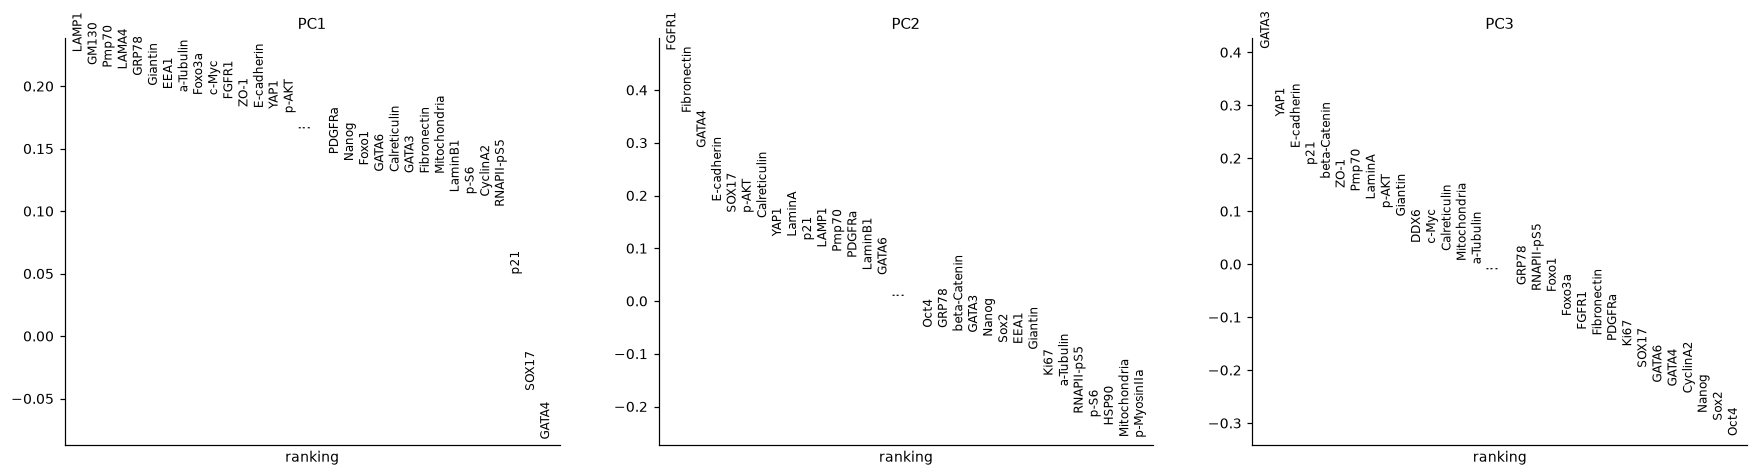

In [5]:
# 1. Plotting PCA loadings with scanpy function
sc.pl.pca_loadings(cells, components = '1,2,3')

In [6]:
# 2. Table plotting
loadings = pd.DataFrame(cells.varm["PCs"][:, :3], index=names, columns=["PC1", "PC2", "PC3"])
loadings.reindex(loadings.PC1.abs().sort_values(ascending=False).index).head(12).round(2)

,PC1,PC2,PC3
LAMP1,0.23,0.10,-0.01
GM130,0.22,-0.01,-0.01
Pmp70,0.21,0.09,0.14
LAMA4,0.21,0.01,-0.04
GRP78,0.21,-0.05,-0.04
Giantin,0.20,-0.09,0.09
EEA1,0.20,-0.08,-0.00
a-Tubulin,0.20,-0.16,-0.00
Foxo3a,0.19,-0.03,-0.10
c-Myc,0.19,-0.00,0.04


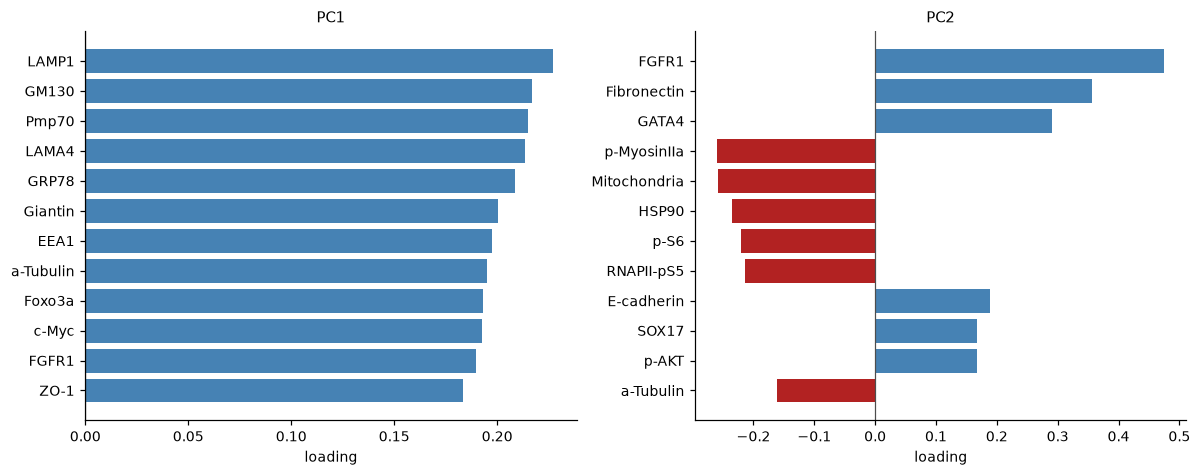

In [7]:
# 3. Costume pca loading functions

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, pc in zip(axes, ["PC1", "PC2"]):
    top = loadings[pc].reindex(loadings[pc].abs().sort_values(ascending=False).index).head(12)[::-1]
    ax.barh(range(len(top)), top.values,
            color=["steelblue" if v > 0 else "firebrick" for v in top.values])
    ax.set(yticks=range(len(top)), yticklabels=top.index, xlabel="loading", title=pc)
    ax.axvline(0, color="0.3", lw=0.8)
fig.tight_layout()

Usually a component is a **contrast** — some markers up, others down — and you read the
two ends against each other.

**PC1 here is quite directional** Mostly every loading is positive, and the largest are all about the same
size. That is the signature of a *magnitude* axis: it is not separating one biology from
another, it is separating cells with more signal from cells with less. However, in the scanpy functions we can also see some that are slightly downregulated, in this dataset this is the type of things you should take into account for the project. And decide which is the best way to plot the data.

That is a guess from the shape of the bars. Check it directly against things PC1 was
never given — the average marker level, the counterstain, cell size, and time:

One way to check possible sources of the different components is using correlations which you can see below.

Be careful because a correlation does not mean causation, and maybe as well that multiple things correlate with your different PCs.

In [8]:
matrix = np.asarray(cells.X)

pd.DataFrame({
    "Spearman vs PC1": {
        "mean of all 38 markers": stats.spearmanr(coords[:, 0], matrix.mean(axis=1)).statistic,
        "DAPI":                   stats.spearmanr(coords[:, 0], cells.obs.dapi).statistic,
        "cell area":              stats.spearmanr(coords[:, 0], cells.obs.area).statistic,
        "timepoint":              stats.spearmanr(coords[:, 0], timepoint).statistic,
    }
}).round(3)

,Spearman vs PC1
mean of all 38 markers,0.993
DAPI,0.725
cell area,-0.625
timepoint,0.167


:::{important}
**PC1 correlates with overall brightness.** It tracks the mean of all 38 markers at ρ ≈ 1.0 — it is
barely a summary, it is that average with extra steps. It rises with DAPI and falls with
cell area, so the cells at its high end are the smaller, more densely stained ones. And
it is essentially uncorrelated with timepoint, so it is not a clock either.

**A third of the variance in this dataset is spent on how bright a cell is** — read the
exact share off the scree plot above. That is normal for imaging data and it is not
useless: brightness reflects real things like nuclear density and cell state.
:::

:::{admonition} Is this a property of the controls, or of the data?
:class: dropdown

A fair worry: these are 32 untreated wells, and a first component that eats half the
variance might be something peculiar to them.

It is not. Run the same PCA on `mcs2026_intensity.h5ad` — all eighteen conditions, 653,000
cells — and PC1 takes **44.5%** against the share printed above, correlating with the
mean of all markers at 0.996 and with DAPI at +0.66. Almost the same numbers.

That is the useful reading: **brightness dominates untreated cells exactly as it dominates
the whole plate**, so it is a property of imaging rather than of anything the compounds
did. Which is the general shape of what the controls are for — a finding that survives
from here to the full dataset is a finding about the measurement.
:::

## 5 · It is already saved

Chapters 07 to 10 all build on this same PCA — a neighbour graph, a UMAP, a PAGA graph and
a diffusion map are computed *from* it rather than from the raw markers.

There is nothing to store: `sc.pp.pca` put the coordinates in `obsm["X_pca"]` and the
loadings in `varm["PCs"]` when it ran. All that is left is to record *what it was fitted
on*, which the object cannot work out for itself, and write the file.

In [10]:
cells.uns["pca"]["features"] = "the 38 normalised markers"
print("  obsm:", list(cells.obsm), " varm:", list(cells.varm))

DATA_OUT = Path("/cluster/project/mcsliberali/file_outputs")
cells.write_h5ad(DATA_OUT / "mcs2026_controls_downstream.h5ad", compression="gzip")
cells

  obsm: ['X_pca']  varm: ['PCs']


AnnData object with n_obs × n_vars = 97177 × 38
    obs: 'label', 'well_name', 'ROI', 'is_border_internal', 'is_border_external', 'Organoid_ID', 'timepoint_h', 'condition', 'condition_code', 'well', 'row', 'column', 'is_outlier_condition', 'area', 'eccentricity', 'solidity', 'extent', 'roundness', 'x_in_well', 'y_in_well', 'dapi', 'in_sketch'
    var: 'family', 'statistic', 'channel', 'round', 'marker', 'species', 'intensity_threshold', 'haralick_threshold', 'failed', 'is_reference', 'is_structural', 'theme', 'column'
    uns: 'decode_report', 'dropped_wells', 'panels', 'provenance', 'subset_conditions', 'subset_of', 'subset_reason', 'themes', 'pca', 'timepoint_h_colors', 'condition_colors', 'row_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'raw'

---

## Exercises

### 1. Is PC1 a clock?

Correlate PC1 with timepoint, and with a marker you would expect to track differentiation.
How much of PC1 is time?

:::{admonition} Solution
:class: dropdown

```python
from scipy import stats
print("PC1 vs timepoint:", stats.spearmanr(coords[:, 0], timepoint).statistic.round(3))
for m in ["Oct4", "SOX17", "Ki67"]:
    print(f"PC1 vs {m}:", stats.spearmanr(coords[:, 0], cells[:, m].X.ravel()).statistic.round(3))
```

If PC1 correlates strongly with time, say so in your figure captions rather than calling
it a phenotype axis. Time is a real biological variable here — the cells are
differentiating — so a time-dominated PC1 is not a bug. It only becomes one when it is
reported as something else.
:::

### 2. Does the outlier condition need removing?

This one needs the **full** object, not the controls: the outlier flagged in
[Step 16](../1_preparation/03_normalisation.ipynb) is a treatment, and there are no
treatments in this file. Fit the PCA on `mcs2026_intensity.h5ad` twice, with and without the
flagged cells. Does the variance explained by PC1 change? Does PC2 start describing
something new?

:::{admonition} Solution
:class: dropdown

```python
full = sc.read_h5ad(DATA / "mcs2026_intensity.h5ad")
kept = full[~full.obs.is_outlier_condition].copy()
sc.pp.pca(full, n_comps=10, random_state=0)
sc.pp.pca(kept, n_comps=10, random_state=0)
print("with the outlier   :", full.uns["pca"]["variance_ratio"][:4].round(3))
print("without the outlier:", kept.uns["pca"]["variance_ratio"][:4].round(3))
```

Whether to exclude it depends on the question. Keep it when you want to know how far a
strong perturbation can push these cells; drop it when you want to resolve structure
among the other seventeen. Both are defensible — doing it without noticing is not.
:::

---

**Next:** [07 · UMAP](07_umap.ipynb).